# Explainable AI on Ames Housing

MICE-XGBoost imputation, a tri-model comparison (Random Forest, Linear
Regression, XGBoost), and model explainability with `dalex`.

**Pipeline**
1. Load and inspect the data
2. Handle structural missingness (domain-driven, not statistical)
3. Split into train/test
4. Impute remaining missingness with MICE-XGBoost, fit on train only
5. Train the tri-model pipeline
6. Explain the models with `dalex` (variable importance, PDP, SHAP)


## 1. Setup

In [1]:
import os

import dalex as dx
import joblib
import kagglehub
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, XGBRegressor

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

## 2. Load data

In [2]:
path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")
df = pd.read_csv(os.path.join(path, "AmesHousing.csv"))

print(f"Shape: {df.shape}")
df.head()

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [5]:
df.describe(include=["object"])

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


## 3. Exploratory overview

In [6]:
print(df.dtypes.value_counts())
print("Duplicate rows:", df.duplicated().sum())

for c in df.select_dtypes(include="object").columns:
    print(f"{c}: {df[c].nunique()} unique values")

object     43
int64      28
float64    11
Name: count, dtype: int64
Duplicate rows: 0
MS Zoning: 7 unique values
Street: 2 unique values
Alley: 2 unique values
Lot Shape: 4 unique values
Land Contour: 4 unique values
Utilities: 3 unique values
Lot Config: 5 unique values
Land Slope: 3 unique values
Neighborhood: 28 unique values
Condition 1: 9 unique values
Condition 2: 8 unique values
Bldg Type: 5 unique values
House Style: 8 unique values
Roof Style: 6 unique values
Roof Matl: 8 unique values
Exterior 1st: 16 unique values
Exterior 2nd: 17 unique values
Mas Vnr Type: 4 unique values
Exter Qual: 4 unique values
Exter Cond: 5 unique values
Foundation: 6 unique values
Bsmt Qual: 5 unique values
Bsmt Cond: 5 unique values
Bsmt Exposure: 4 unique values
BsmtFin Type 1: 6 unique values
BsmtFin Type 2: 6 unique values
Heating: 6 unique values
Heating QC: 5 unique values
Central Air: 2 unique values
Electrical: 5 unique values
Kitchen Qual: 5 unique values
Functional: 8 unique values
Firepla

In [7]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(2)

missing_table = pd.concat(
    [missing_summary, missing_pct], axis=1, keys=["n_missing", "pct_missing"]
)
missing_table = missing_table[missing_table["n_missing"] > 0]
missing_table

,n_missing,pct_missing
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Cond,159,5.43
Garage Finish,159,5.43
Garage Yr Blt,159,5.43


In [8]:
df.skew(numeric_only=True).sort_values(ascending=False)

Misc Val           21.999788
Pool Area          16.939142
Lot Area           12.820898
Low Qual Fin SF    12.118162
3Ssn Porch         11.403795
Kitchen AbvGr       4.313825
BsmtFin SF 2        4.139978
Enclosed Porch      4.014446
Screen Porch        3.957467
Bsmt Half Bath      3.940795
Mas Vnr Area        2.606985
Open Porch SF       2.535386
Wood Deck SF        1.842678
SalePrice           1.743500
Lot Frontage        1.499067
1st Flr SF          1.469429
BsmtFin SF 1        1.416182
MS SubClass         1.357579
Gr Liv Area         1.274110
Total Bsmt SF       1.156204
Bsmt Unf SF         0.923053
2nd Flr SF          0.866457
TotRms AbvGrd       0.753543
Fireplaces          0.739215
Half Bath           0.697713
Bsmt Full Bath      0.616639
Overall Cond        0.574429
Bedroom AbvGr       0.305694
Garage Area         0.241994
Mo Sold             0.192596
Overall Qual        0.190634
Full Bath           0.171952
Yr Sold             0.134862
PID                 0.055886
Order         

`SalePrice` is right-skewed (skew ~1.74), consistent with typical house price
distributions. This motivates modeling `log(SalePrice)` rather than raw price.

Several columns show very high missingness (`Pool QC`, `Misc Feature`,
`Fireplace Qu`, etc.) — the next step checks whether that missingness is
structural (the feature genuinely doesn't exist for that house) rather than
data that is Missing at Random.

## 4. Structural missingness

For several categorical columns, `NaN` does not mean "unknown" — it means the
house does not have that feature (e.g. `Pool QC` is `NaN` because the house
has no pool). These are filled with an explicit `"None"` category rather than
being treated as a statistical imputation problem, and cross-checked against
the related numeric/count column.

This step uses only deterministic domain rules, not any fitted statistic, so
it is applied before the train/test split without introducing leakage.

In [9]:
structural_none_cols = [
    "Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu",
    "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
    "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2",
    "Mas Vnr Type",
]

# Sanity check: does NaN align with 0 in the related area/count column?
checks = {
    "Fireplace Qu": "Fireplaces",
    "Garage Type": "Garage Area",
    "Bsmt Qual": "Total Bsmt SF",
    "Mas Vnr Type": "Mas Vnr Area",
}

for cat_col, area_col in checks.items():
    mismatch = df[df[cat_col].isna() & (df[area_col] != 0)]
    print(f"{cat_col}: {len(mismatch)} rows where NaN but {area_col} != 0")

Fireplace Qu: 0 rows where NaN but Fireplaces != 0
Garage Type: 0 rows where NaN but Garage Area != 0
Bsmt Qual: 1 rows where NaN but Total Bsmt SF != 0
Mas Vnr Type: 30 rows where NaN but Mas Vnr Area != 0


In [10]:
df_clean = df.copy()

for c in structural_none_cols:
    df_clean[c] = df_clean[c].fillna("None")

# No garage means no garage build year
df_clean["Garage Yr Blt"] = df_clean["Garage Yr Blt"].fillna(0)

remaining_missing = df_clean.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
remaining_missing

Lot Frontage      490
Mas Vnr Area       23
Bsmt Full Bath      2
Bsmt Half Bath      2
BsmtFin SF 1        1
BsmtFin SF 2        1
Bsmt Unf SF         1
Total Bsmt SF       1
Electrical          1
Garage Cars         1
Garage Area         1
dtype: int64

The remaining missing columns (`Lot Frontage`, `Mas Vnr Area`, `Electrical`,
a handful of `Bsmt`/`Garage` fields) have no structural explanation and are
treated as Missing at Random — these are the actual imputation targets.

## 5. Train/test split

The split happens **before** any statistically fitted step (imputation,
encoding, modeling), so nothing downstream is fit on information from the
test set.

In [11]:
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=RANDOM_STATE)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Train: (2344, 82), Test: (586, 82)


## 6. MICE-XGBoost imputation

Multiple Imputation by Chained Equations, implemented manually with
`XGBRegressor` for numeric columns and `XGBClassifier` for categorical
columns, since `IterativeImputer` does not support mixed estimator types.

To avoid leakage, imputation follows a fit/transform pattern:

- **Fit** — the chained-equations loop trains its models using only the
  training rows.
- **Transform** — the test set is imputed using those already-fitted models
  (no refitting on test data), applied iteratively to let the test set's own
  feature values converge.

Categorical encoding follows the same rule: label encoders are fit on the
training set's categories only. Any category seen in test but not in train is
mapped to the training set's most frequent category for that column before
encoding.

In [13]:
def fit_label_encoders(data, columns):
    encoders, fallback = {}, {}
    for c in columns:
        non_null = data[c].dropna()
        le = LabelEncoder()
        le.fit(non_null)
        encoders[c] = le
        fallback[c] = non_null.mode()[0]
    return encoders, fallback


def apply_label_encoders(data, columns, encoders, fallback):
    data_enc = data.copy()
    for c in columns:
        mask = data_enc[c].notna()
        vals = data_enc.loc[mask, c]
        vals = vals.where(vals.isin(encoders[c].classes_), fallback[c])
        data_enc.loc[mask, c] = encoders[c].transform(vals)
        data_enc[c] = data_enc[c].astype(float)
    return data_enc


encoders, fallback = fit_label_encoders(train_df, cat_cols)
train_enc = apply_label_encoders(train_df, cat_cols, encoders, fallback)
test_enc = apply_label_encoders(test_df, cat_cols, encoders, fallback)

In [14]:
def initial_fill_stats(data, numeric_columns, categorical_columns):
    means = {c: data[c].mean() for c in numeric_columns}
    modes = {c: data[c].mode()[0] for c in categorical_columns}
    return means, modes


def apply_initial_fill(data, means, modes):
    data_filled = data.copy()
    for c, v in means.items():
        data_filled[c] = data_filled[c].fillna(v)
    for c, v in modes.items():
        data_filled[c] = data_filled[c].fillna(v)
    return data_filled


def fit_mice_xgboost(data_enc, numeric_columns, categorical_columns, n_iter=10, seed=0):
    """Fit the chained-equations loop on training data only."""
    means, modes = initial_fill_stats(data_enc, numeric_columns, categorical_columns)
    current = apply_initial_fill(data_enc, means, modes)

    missing_mask = data_enc.isna()
    cols_with_missing = [c for c in data_enc.columns if missing_mask[c].any()]
    fitted_models = {}

    for it in range(n_iter):
        for c in cols_with_missing:
            missing_idx = missing_mask[missing_mask[c]].index
            observed_idx = data_enc[data_enc[c].notna()].index

            X_obs = current.drop(columns=[c]).loc[observed_idx]
            y_obs = current.loc[observed_idx, c]
            X_miss = current.drop(columns=[c]).loc[missing_idx]

            if c in numeric_columns:
                model = XGBRegressor(
                    n_estimators=150, max_depth=4, learning_rate=0.1,
                    random_state=seed + it, verbosity=0,
                )
                model.fit(X_obs, y_obs)
            else:
                model = XGBClassifier(
                    n_estimators=150, max_depth=4, learning_rate=0.1,
                    random_state=seed + it, verbosity=0, eval_metric="mlogloss",
                )
                model.fit(X_obs, y_obs.astype(int))

            if len(missing_idx):
                current.loc[missing_idx, c] = model.predict(X_miss)
            fitted_models[c] = model

    return current, fitted_models, means, modes, cols_with_missing


def transform_mice_xgboost(data_enc, fitted_models, means, modes, cols_with_missing, n_iter=10):
    """Impute new data using models already fit on the training set."""
    current = apply_initial_fill(data_enc, means, modes)
    missing_mask = data_enc.isna()

    for _ in range(n_iter):
        for c in cols_with_missing:
            if c not in missing_mask.columns:
                continue
            missing_idx = missing_mask[missing_mask[c]].index
            if len(missing_idx) == 0:
                continue
            X_miss = current.drop(columns=[c]).loc[missing_idx]
            current.loc[missing_idx, c] = fitted_models[c].predict(X_miss)

    return current

In [15]:
M = 5
train_imputed, test_imputed = [], []

for m in range(M):
    train_completed, models_m, means_m, modes_m, cols_with_missing = fit_mice_xgboost(
        train_enc, numeric_cols, cat_cols, n_iter=10, seed=m * 100
    )
    test_completed = transform_mice_xgboost(
        test_enc, models_m, means_m, modes_m, cols_with_missing, n_iter=10
    )
    train_imputed.append(train_completed)
    test_imputed.append(test_completed)

print(f"Generated {M} imputed train/test dataset pairs.")
print("Columns imputed:", cols_with_missing)

Generated 5 imputed train/test dataset pairs.
Columns imputed: ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Electrical', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area']


## 7. Decode and pool

In [16]:
def decode_categoricals(data_imputed, columns, encoders):
    decoded = data_imputed.copy()
    for c in columns:
        codes = decoded[c].round().astype(int).clip(0, len(encoders[c].classes_) - 1)
        decoded[c] = encoders[c].inverse_transform(codes)
    return decoded


def pool_imputed_values(datasets, numeric_columns, categorical_columns):
    pooled = datasets[0].copy()

    for c in numeric_columns:
        stacked = np.stack([d[c].values for d in datasets], axis=0)
        pooled[c] = stacked.mean(axis=0)

    for c in categorical_columns:
        stacked = pd.concat([d[c] for d in datasets], axis=1)
        pooled[c] = stacked.mode(axis=1)[0]

    return pooled


train_decoded = [decode_categoricals(d, cat_cols, encoders) for d in train_imputed]
test_decoded = [decode_categoricals(d, cat_cols, encoders) for d in test_imputed]

pooled_train_df = pool_imputed_values(train_decoded, numeric_cols, cat_cols)
pooled_test_df = pool_imputed_values(test_decoded, numeric_cols, cat_cols)

joblib.dump(pooled_train_df, "pooled_train_df.pkl")
joblib.dump(pooled_test_df, "pooled_test_df.pkl")

pooled_train_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2073,2074.0,905352180.0,60.0,RL,97.000000,10029.0,Pave,None,IR1,Lvl,...,0.0,None,None,None,0.0,9.0,2007.0,WD,Normal,211000.0
2754,2755.0,906382030.0,20.0,RL,86.000000,11210.0,Pave,None,IR1,Lvl,...,0.0,None,None,None,0.0,7.0,2006.0,New,Partial,221500.0
1282,1283.0,535477090.0,20.0,RL,69.000000,7590.0,Pave,None,Reg,Lvl,...,0.0,None,None,None,0.0,5.0,2008.0,COD,Normal,136870.0
1572,1573.0,916325080.0,20.0,RL,104.760109,15498.0,Pave,None,IR1,Lvl,...,0.0,None,None,None,0.0,5.0,2008.0,COD,Abnorml,287000.0
641,642.0,535302120.0,90.0,RL,76.000000,9482.0,Pave,None,Reg,Lvl,...,0.0,None,None,None,0.0,12.0,2009.0,WD,Normal,135000.0


## 8. Sanity checks

In [17]:
print("Remaining NaNs — train:", pooled_train_df.isna().sum().sum())
print("Remaining NaNs — test:", pooled_test_df.isna().sum().sum())

missing_rows_lf = train_df[train_df["Lot Frontage"].isna()].index
print(pooled_train_df.loc[missing_rows_lf, "Lot Frontage"].describe())

print("Observed Lot Frontage range:", df["Lot Frontage"].min(), "-", df["Lot Frontage"].max())
print(
    "Imputed Lot Frontage range:",
    pooled_train_df.loc[missing_rows_lf, "Lot Frontage"].min(), "-",
    pooled_train_df.loc[missing_rows_lf, "Lot Frontage"].max(),
)

Remaining NaNs — train: 0
Remaining NaNs — test: 0
count    409.000000
mean      73.793689
std       19.171650
min       22.516586
25%       62.732899
50%       74.187233
75%       84.769768
max      144.068802
Name: Lot Frontage, dtype: float64
Observed Lot Frontage range: 21.0 - 313.0
Imputed Lot Frontage range: 22.516586303710938 - 144.0688018798828


## 9. Modeling

Categoricals are one-hot encoded, fit on the training set and aligned onto
the test set so both share the exact same columns. The target is
`log(SalePrice)`, given its right skew.

Linear Regression drops `Total Bsmt SF`, which is an exact linear combination
of three other basement columns (`BsmtFin SF 1 + BsmtFin SF 2 + Bsmt Unf SF`).
Left in, this causes perfect multicollinearity and produces numerically
meaningless coefficients for a least-squares fit. Tree-based models are
unaffected by this and keep the full feature set.

In [18]:
drop_cols = ["Order", "PID", "SalePrice"]

X_train_raw = pooled_train_df.drop(columns=[c for c in drop_cols if c in pooled_train_df.columns])
X_test_raw = pooled_test_df.drop(columns=[c for c in drop_cols if c in pooled_test_df.columns])

y_train = np.log1p(pooled_train_df["SalePrice"])
y_test = np.log1p(pooled_test_df["SalePrice"])

model_cat_cols = X_train_raw.select_dtypes(include="object").columns.tolist()

X_train = pd.get_dummies(X_train_raw, columns=model_cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test_raw, columns=model_cat_cols, drop_first=True)

# Align test columns to train (handles categories seen in only one split)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train_lr = X_train.drop(columns=["Total Bsmt SF"])
X_test_lr = X_test.drop(columns=["Total Bsmt SF"])

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (2344, 271), X_test: (586, 271)


In [19]:
rf_regr = RandomForestRegressor(
    n_estimators=300, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1,
)

l_regr = LinearRegression()

xgb_regr = XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    tree_method="hist", random_state=RANDOM_STATE, eval_metric="rmse",
)

rf_regr.fit(X_train, y_train)
l_regr.fit(X_train_lr, y_train)
xgb_regr.fit(X_train, y_train)

joblib.dump(rf_regr, "rf_regr.pkl")
joblib.dump(l_regr, "l_regr.pkl")
joblib.dump(xgb_regr, "xgb_regr.pkl")

print("All three models fitted.")

All three models fitted.


### Test-set performance (dollar scale)

In [20]:
def evaluate(name, model, X, y_true_log):
    y_pred = np.expm1(model.predict(X))
    y_true = np.expm1(y_true_log)
    print(
        f"{name:<20} "
        f"MAE: ${mean_absolute_error(y_true, y_pred):,.0f}   "
        f"RMSE: ${np.sqrt(mean_squared_error(y_true, y_pred)):,.0f}   "
        f"R2: {r2_score(y_true, y_pred):.4f}"
    )


evaluate("Random Forest", rf_regr, X_test, y_test)
evaluate("Linear Regression", l_regr, X_test_lr, y_test)
evaluate("XGBoost", xgb_regr, X_test, y_test)

Random Forest        MAE: $19,488   RMSE: $32,331   R2: 0.8408
Linear Regression    MAE: $172,903   RMSE: $190,074   R2: -4.5030
XGBoost              MAE: $14,102   RMSE: $25,294   R2: 0.9025


## 10. Explainability with dalex

Explainers are built on the held-out test set. Predictions are back-transformed
from log-dollars to dollars via `predict_function`.

In [21]:
y_test_dollars = np.expm1(y_test)

rf_exp = dx.Explainer(
    rf_regr, X_test, y_test_dollars,
    label="Random Forest",
    predict_function=lambda m, d: np.expm1(m.predict(d)),
)

lr_exp = dx.Explainer(
    l_regr, X_test_lr, y_test_dollars,
    label="Linear Regression",
    predict_function=lambda m, d: np.expm1(m.predict(d)),
)

xgb_exp = dx.Explainer(
    xgb_regr, X_test, y_test_dollars,
    label="XGBoost",
    predict_function=lambda m, d: np.expm1(m.predict(d)),
)

Preparation of a new explainer is initiated

  -> data              : 586 rows 271 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 586 values
  -> model_class       : sklearn.ensemble._forest.RandomForestRegressor (default)
  -> label             : Random Forest
  -> predict function  : <function <lambda> at 0x000001F461F3BC40> will be used
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 5.14e+04, mean = 1.8e+05, max = 4.87e+05
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -3.02e+05, mean = 3.25e+03, max = 1.97e+05
  -> model_info        : package sklearn

A new explainer has been created!
Preparation of a new explainer is initiated

  -> data              : 586 rows 270 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.n

### Variable importance

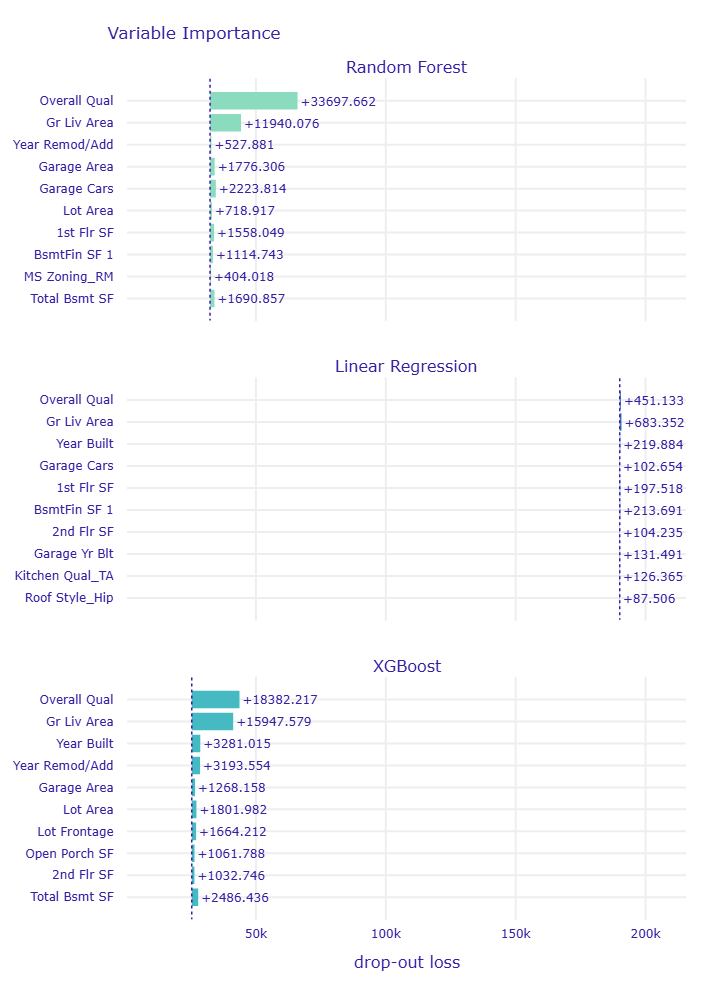

In [22]:
rf_exp.model_parts().plot([lr_exp.model_parts(), xgb_exp.model_parts()])

### Partial dependence profiles

`Total Bsmt SF` is excluded from Linear Regression's feature set (see the
multicollinearity note above), so it is compared separately with only the
two tree-based models.

Calculating ceteris paribus: 100%|██████████████████████████████████████| 1/1 [00:00<00:00,  5.30it/s]


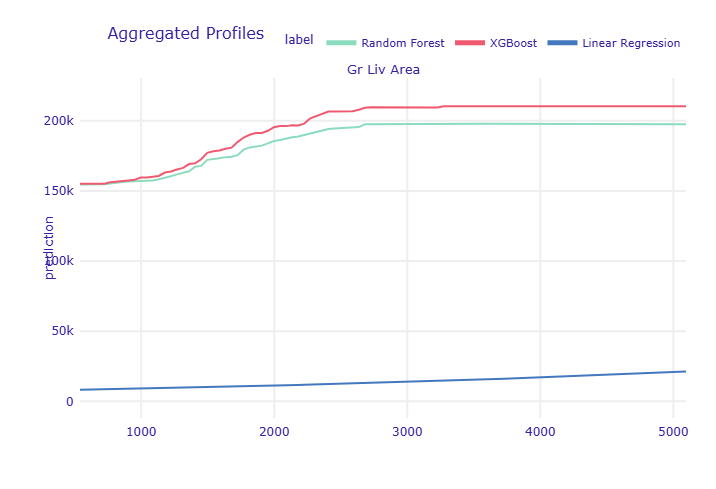

In [23]:
def compare_pdp(variable, include_lr=True):
    rf_pdp = rf_exp.model_profile(type="partial", variables=[variable])
    xgb_pdp = xgb_exp.model_profile(type="partial", variables=[variable])

    others = [xgb_pdp]
    if include_lr and variable in X_test_lr.columns:
        others.append(lr_exp.model_profile(type="partial", variables=[variable]))

    rf_pdp.plot(others)


compare_pdp("Gr Liv Area")

Calculating ceteris paribus: 100%|██████████████████████████████████████| 1/1 [00:00<00:00,  6.03it/s]


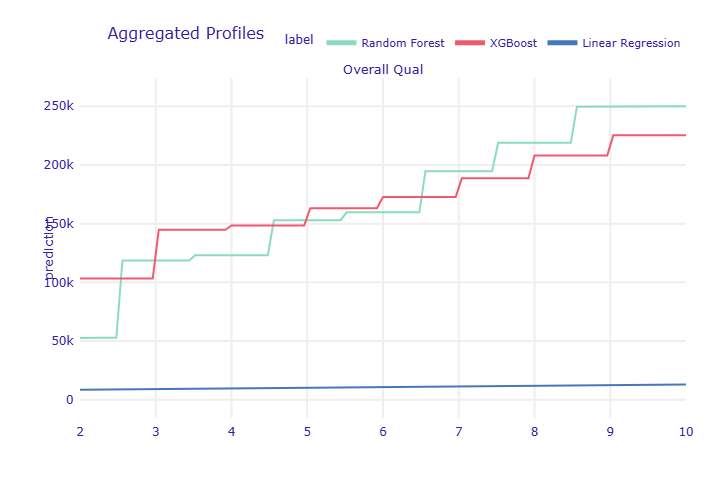

In [24]:
compare_pdp("Overall Qual")

### Local explanations (SHAP)

Per-observation SHAP values decompose an individual prediction into each
feature's contribution, in dollars.

--- Observation 0 ---


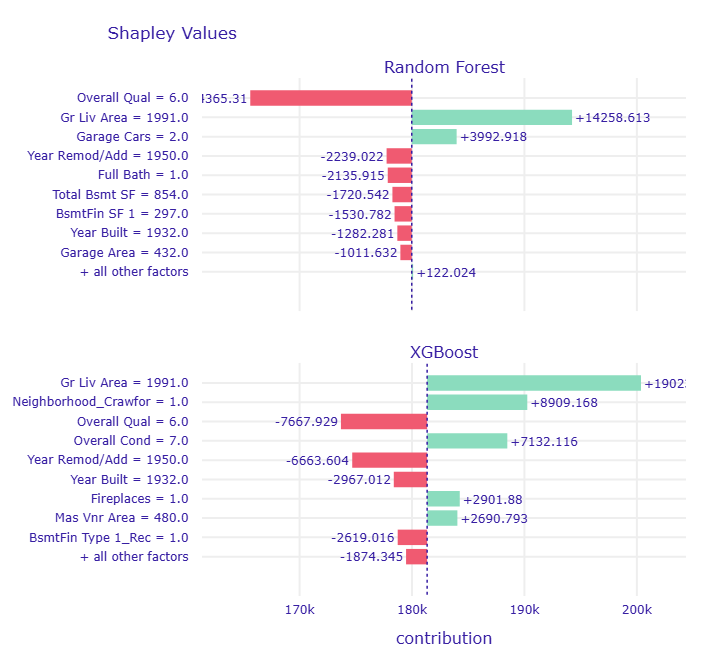

--- Observation 5 ---


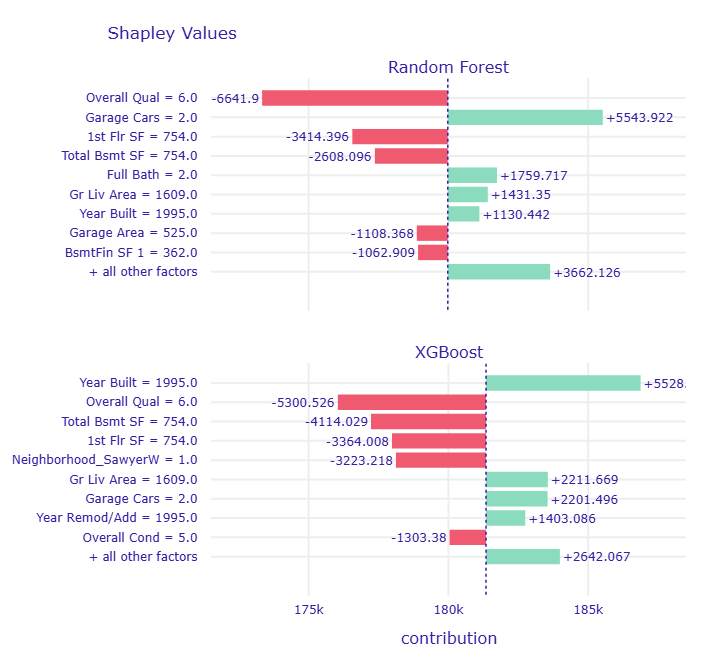

--- Observation 20 ---


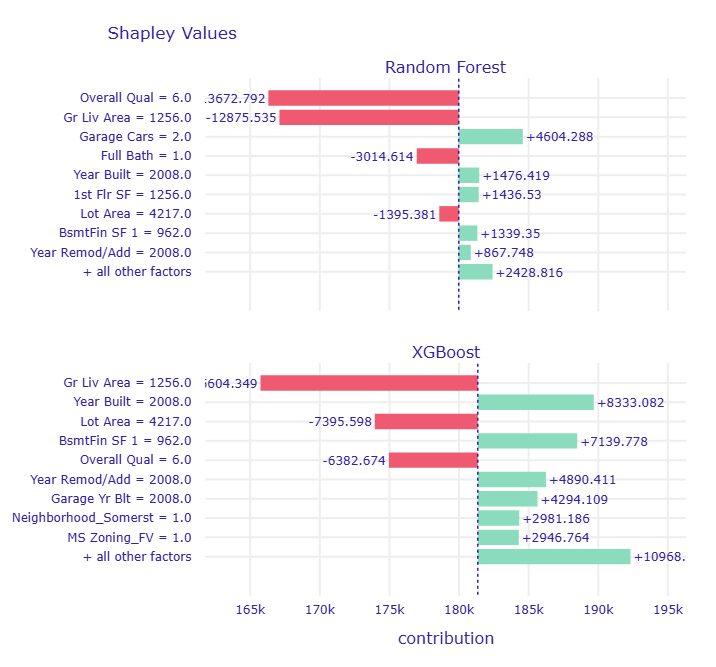

In [25]:
for idx in [0, 5, 20]:
    obs = X_test.iloc[[idx]]
    obs_lr = X_test_lr.iloc[[idx]]

    rf_shap = rf_exp.predict_parts(obs, type="shap", B=25)
    xgb_shap = xgb_exp.predict_parts(obs, type="shap", B=25)

    print(f"--- Observation {idx} ---")
    rf_shap.plot([xgb_shap])

## Summary

- Structural missingness (e.g. `Pool QC`, `Fireplace Qu`) was separated from
  genuine Missing at Random gaps before any statistical imputation.
- MICE-XGBoost imputation was fit only on the training set and applied to the
  test set through a fit/transform pattern, avoiding data leakage.
- Linear Regression required dropping a redundant, perfectly collinear
  feature (`Total Bsmt SF`); tree-based models were unaffected.
- Random Forest and XGBoost track each other closely and plateau in sparse
  regions of the feature space (e.g. very large houses), while Linear
  Regression continues extrapolating linearly — a clear illustration of how
  model choice affects behavior outside the dense region of the data.